In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.base import clone
from collections import Counter
from scipy import stats
from sklearn.base import BaseEstimator, ClassifierMixin

#Carregando o dataset

In [ ]:
!wget -O jogos.csv 'https://drive.google.com/uc?export=download&id=1vWz_B1ZyGTEaXRfeyxGmt8W9Hg6R8gb8'

--2025-07-10 01:25:46--  https://drive.google.com/uc?export=download&id=1vWz_B1ZyGTEaXRfeyxGmt8W9Hg6R8gb8
Resolving drive.google.com (drive.google.com)... 108.177.11.138, 108.177.11.101, 108.177.11.100, ...
Connecting to drive.google.com (drive.google.com)|108.177.11.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1vWz_B1ZyGTEaXRfeyxGmt8W9Hg6R8gb8&export=download [following]
--2025-07-10 01:25:46--  https://drive.usercontent.google.com/download?id=1vWz_B1ZyGTEaXRfeyxGmt8W9Hg6R8gb8&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 173.194.210.132, 2607:f8b0:400c:c0f::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|173.194.210.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1597344 (1.5M) [application/octet-stream]
Saving to: ‘jogos.csv’

jogos.csv           100%[===================>]   1.52M  --.-KB/s   

In [ ]:
df = pd.read_csv('jogos.csv')

# print(df.to_string())

#Pré-processamento


Aqui filtrarei apenas as colunas que vou utilizar, no meu caso as colunas de dados aos 10 minutos e pré-jogo

In [ ]:
colunas_desejadas = ['result', 'golddiffat10', 'xpdiffat10', 'csdiffat10', 'killsdiffat10', 'assistsdiffat10', 'WR', 'KD', 'GPR', 'GSPD', 'EGR',
        'MLR', 'FB%', 'FT%', 'F3T%', 'HLD%', 'DRG%', 'BN%', 'LNE%', 'JNG%', 'OPP_WR', 'OPP_KD', 'OPP_GPR', 'OPP_GSPD',
        'OPP_EGR', 'OPP_MLR', 'OPP_FB%', 'OPP_FT%', 'OPP_F3T%', 'OPP_HLD%', 'OPP_DRG%', 'OPP_BN%', 'OPP_LNE%', 'OPP_JNG%']
df = df[colunas_desejadas]

print(df)

      result  golddiffat10  xpdiffat10  csdiffat10  killsdiffat10  \
0          1        1793.0      2365.0        65.0            1.0   
1          0         759.0       171.0        -8.0            1.0   
2          0          73.0        -1.0       -24.0            1.0   
3          1        1746.0       824.0        21.0            2.0   
4          0       -3500.0     -1882.0       -18.0           -7.0   
...      ...           ...         ...         ...            ...   
8147       1        1928.0       469.0        -4.0            3.0   
8148       0       -1325.0      -677.0       -20.0           -1.0   
8149       0         671.0      1446.0       -20.0            2.0   
8150       0        1002.0       -72.0       -40.0            4.0   
8151       1         -17.0      -280.0        -6.0           -1.0   

      assistsdiffat10        WR    KD   GPR  GSPD  ...  OPP_EGR  OPP_MLR  \
0                 0.0  1.000000  2.13  2.42  12.6  ...     23.1    -23.1   
1                 3

In [ ]:
df.head()

,result,golddiffat10,xpdiffat10,csdiffat10,killsdiffat10,assistsdiffat10,WR,KD,GPR,GSPD,...,OPP_EGR,OPP_MLR,OPP_FB%,OPP_FT%,OPP_F3T%,OPP_HLD%,OPP_DRG%,OPP_BN%,OPP_LNE%,OPP_JNG%
0,1,1793.0,2365.0,65.0,1.0,0.0,1.000000,2.13,2.42,12.6,...,23.1,-23.1,0,0,33,50,27,0,49.2,43.7
1,0,759.0,171.0,-8.0,1.0,3.0,0.000000,0.29,-1.75,-12.1,...,77.2,22.8,100,100,100,58,70,89,50.4,53.3
2,0,73.0,-1.0,-24.0,1.0,-1.0,0.000000,0.29,-1.75,-12.1,...,77.2,22.8,100,100,100,58,70,89,50.4,53.3
3,1,1746.0,824.0,21.0,2.0,2.0,1.000000,3.26,5.80,30.4,...,63.9,-3.9,67,67,67,48,60,48,51.6,50.3
4,0,-3500.0,-1882.0,-18.0,-7.0,-11.0,0.636364,0.92,-0.19,-3.6,...,25.8,-0.8,13,25,25,19,20,20,49.7,42.2


In [ ]:
#Convertendo os valores das colunas de string para numerico
df['result'] = pd.to_numeric(df['result'], downcast='integer', errors='coerce')
for col in df:
  if col != 'result':
    df[col] = pd.to_numeric(df[col], downcast='float', errors='coerce')

print(df)

      result  golddiffat10  xpdiffat10  csdiffat10  killsdiffat10  \
0          1        1793.0      2365.0        65.0            1.0   
1          0         759.0       171.0        -8.0            1.0   
2          0          73.0        -1.0       -24.0            1.0   
3          1        1746.0       824.0        21.0            2.0   
4          0       -3500.0     -1882.0       -18.0           -7.0   
...      ...           ...         ...         ...            ...   
8147       1        1928.0       469.0        -4.0            3.0   
8148       0       -1325.0      -677.0       -20.0           -1.0   
8149       0         671.0      1446.0       -20.0            2.0   
8150       0        1002.0       -72.0       -40.0            4.0   
8151       1         -17.0      -280.0        -6.0           -1.0   

      assistsdiffat10        WR    KD   GPR  GSPD  ...    OPP_EGR    OPP_MLR  \
0                 0.0  1.000000  2.13  2.42  12.6  ...  23.100000 -23.100000   
1          

Aqui analisarei se existe algum valor nulo na base de dados para, se necessário, filtrar os dados. E também analisarei algumas métricas importantes como média, desvio padrão (que são usados para padronização)

In [ ]:
print(df.isnull().sum())
print(df.describe(include='all'))

result             0
golddiffat10       0
xpdiffat10         0
csdiffat10         0
killsdiffat10      0
assistsdiffat10    0
WR                 0
KD                 0
GPR                0
GSPD               0
EGR                0
MLR                0
FB%                0
FT%                0
F3T%               0
HLD%               0
DRG%               0
BN%                0
LNE%               0
JNG%               0
OPP_WR             0
OPP_KD             0
OPP_GPR            0
OPP_GSPD           0
OPP_EGR            0
OPP_MLR            0
OPP_FB%            0
OPP_FT%            0
OPP_F3T%           0
OPP_HLD%           0
OPP_DRG%           0
OPP_BN%            0
OPP_LNE%           0
OPP_JNG%           0
dtype: int64
            result  golddiffat10   xpdiffat10   csdiffat10  killsdiffat10  \
count  8152.000000   8152.000000  8152.000000  8152.000000    8152.000000   
mean      0.531894    102.689896    32.706451     0.719946       0.090898   
std       0.499012   1520.042236  1138.075

##Usando os classificadores

Separando os dados do target (result).

In [ ]:
df_x = df.drop('result', axis=1)
df_y = df['result']

In [ ]:
def classification_report(scores):
    print(f'Media: {scores.mean():.2f}, Desvio Padrao: {scores.std():.2f}')
    inf, sup = stats.norm.interval(0.95, loc=scores.mean(),
                               scale=scores.std()/np.sqrt(len(scores)))
    print(f'Intervalo de confiança (95%): [{inf:.2f},{sup:.2f}]')

In [ ]:
scalar = StandardScaler()

rkf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=36854321)

modelos = [
    ("DT", DecisionTreeClassifier(random_state=13), {
      'estimator__criterion': ['gini','entropy'],
      'estimator__max_depth': [5, 10, 15, 25]
    }),

    ("KNN", KNeighborsClassifier(), {
      'estimator__n_neighbors':[1,3,5,7,9]
    }),

    # Coloquei o early_stopping=True pois o MLP estava demorando muito para completar (mais de 3 horas e nada de resultados)
    # Tirei dúvida em relação ao early_stopping e foi autorizado
    ("MLP", MLPClassifier(random_state=13, early_stopping=True), {
      'estimator__hidden_layer_sizes': [(100,),(10,)],
      'estimator__alpha': [0.0001, 0.005],
      'estimator__learning_rate': ['constant','adaptive']
    }),

    ("RF", RandomForestClassifier(random_state=13), {
      'estimator__n_estimators': [5, 10, 15, 25],
      'estimator__max_depth': [10, None]
    }),
]

In [ ]:
resultados = {}

for nome, modelo, grade in modelos:
  print(f"\nModelo: {nome}")
  pipeline = Pipeline([('transformer', scalar), ('estimator', modelo)])

  gs = GridSearchCV(estimator=pipeline, param_grid=grade, n_jobs=-1, cv=4)
  scores = cross_val_score(gs, df_x, df_y, cv=rkf)

  print("Scores:", scores)
  print("Média de acurácia:", scores.mean())
  classification_report(scores)
  resultados[nome] = scores


Modelo: DT
Scores: [0.69607843 0.66666667 0.69079755 0.71165644 0.70920245 0.71288344
 0.68466258 0.73742331 0.7006135  0.68957055 0.66666667 0.65563725
 0.7006135  0.73006135 0.69447853 0.68466258 0.67852761 0.72515337
 0.7006135  0.69325153 0.6997549  0.7254902  0.68220859 0.70797546
 0.68466258 0.72515337 0.70920245 0.72392638 0.68957055 0.70674847]
Média de acurácia: 0.69946379165163
Media: 0.70, Desvio Padrao: 0.02
Intervalo de confiança (95%): [0.69,0.71]

Modelo: KNN
Scores: [0.67892157 0.66176471 0.65766871 0.69815951 0.68466258 0.68466258
 0.66871166 0.68466258 0.66871166 0.68711656 0.66789216 0.62867647
 0.69693252 0.6993865  0.66871166 0.66871166 0.69079755 0.68588957
 0.66748466 0.66993865 0.64460784 0.69485294 0.68343558 0.67361963
 0.6392638  0.68343558 0.6809816  0.69079755 0.66625767 0.67239264]
Média de acurácia: 0.674970277477044
Media: 0.67, Desvio Padrao: 0.02
Intervalo de confiança (95%): [0.67,0.68]

Modelo: MLP
Scores: [0.71323529 0.68382353 0.7006135  0.7116564

In [ ]:
linhas = []

for nome, scores in resultados.items():
    media = scores.mean()
    desvio = scores.std()
    inf, sup = stats.norm.interval(0.95, loc=scores.mean(),
                               scale=scores.std()/np.sqrt(len(scores)))
    linhas.append([nome, media, desvio, inf, sup])

tabela = pd.DataFrame(linhas, columns=["Método", "Média", "Desvio Padrão", "Limite Inferior", "Limite Superior"])
print("\nTabela de Resultados:")
print(tabela.round(2))


Tabela de Resultados:
  Método  Média  Desvio Padrão  Limite Inferior  Limite Superior
0     DT   0.70           0.02             0.69             0.71
1    KNN   0.67           0.02             0.67             0.68
2    MLP   0.72           0.02             0.71             0.72
3     RF   0.71           0.02             0.70             0.72


In [ ]:
def t_corrigido_nadeau_bengio(data1, data2, X, n_folds_externos):
    """
    Parâmetros:
        data1, data2: listas ou arrays com as acurácias
        X: conjunto de dados original
        n_folds_externos: número de folds no loop externo
    Retorna:
        t_stat: valor da estatística t
        p_valor: valor-p do teste bilateral
    """
    N = len(X)  # número total de amostras no dataset
    n = len(data1)  # número de execuções
    # Tamanhos dos conjuntos de treino/teste em cada fold externo
    n_test = N // n_folds_externos
    n_train = N - n_test
    # Cálculo da estatística t com correção
    diffs = np.array(data1) - np.array(data2)
    mean_diff = np.mean(diffs)
    std_diff = np.std(diffs, ddof=1)
    se_corrigido = std_diff * np.sqrt(1/n + n_test/n_train)
    t_stat = mean_diff / se_corrigido
    p_valor = 2 * (1 - stats.t.cdf(abs(t_stat), df=n - 1))
    return t_stat, p_valor

print('\nCorrected T Test')
s,p = t_corrigido_nadeau_bengio(resultados["MLP"],resultados["RF"],df,10)
print("t: %0.2f p-value: %0.2f\n" % (s,p))


Corrected T Test
t: 1.02 p-value: 0.32



In [ ]:
def states_total_value(states):
    total_sum = 0
    for state in states:
        total_sum = total_sum + state[0]
    return total_sum

In [ ]:
def roulette_construction(states):
    aux_states = []
    roulette = []
    total_value = states_total_value(states)

    for state in states:
        value = state[0]
        if total_value != 0:
            ratio = value/total_value
        else:
            ratio = 1
        aux_states.append((ratio,state[1]))

    acc_value = 0
    for state in aux_states:
        acc_value = acc_value + state[0]
        s = (acc_value,state[1])
        roulette.append(s)
    return roulette

In [ ]:
roulette_construction([(1, [1,0,0]), (4, [0, 1, 0]), (5, [0, 0, 1])])

[(0.1, [1, 0, 0]), (0.5, [0, 1, 0]), (1.0, [0, 0, 1])]

In [ ]:
import random

def roulette_run (rounds, roulette):
    if roulette == []:
        return []
    selected = []
    while len(selected) < rounds:
        r = random.uniform(0,1)
        for state in roulette:
            if r <= state[0]:
                selected.append(state[1])
                break
    return selected

In [ ]:
roulette_run (1, [(0.1, [1, 0, 0]), (0.5, [0, 1, 0]), (1.0, [0, 0, 1])])

[[0, 0, 1]]

In [ ]:
class HeterogeneousBoosting(BaseEstimator, ClassifierMixin): #Herda de BaseEstimator e ClassifierMixin para poder ser usado em cross_val_score
    def __init__(self, n_estimators=50):
        self.n_estimators = n_estimators

    def fit(self, X, y):
        self.classe_mais_frequente = y.mode()[0]
        X = np.array(X)
        y = np.array(y)
        self.models = []


        pesos = np.ones(len(X))

        classificadores_base = [
            ("MLP", MLPClassifier(early_stopping=True, random_state=13)),
            ("DT", DecisionTreeClassifier(random_state=13)),
            ("KNN", KNeighborsClassifier()),
            ("GNB", GaussianNB())
        ]

        for i in range(self.n_estimators):
            states = list(zip(pesos, range(len(X)))) #Cria uma lista de tuplas peso, index
            roleta = roulette_construction(states)
            idx_selecionado = roulette_run(len(X), roleta) #Seleciona os conjuntos com base no algoritmo da roleta
            X_sample = X[idx_selecionado]
            y_sample = y[idx_selecionado]

            melhor_score = -1
            melhor_modelo = None
            nome_melhor_modelo = None
            for nome, classificador in classificadores_base: #Para cada um dos métodos de classificação treina, testa
                modelo = classificador.__class__(**classificador.get_params())
                modelo.fit(X_sample, y_sample)
                previsoes = modelo.predict(X_sample)
                acuracia = (previsoes == y_sample).mean()
                if acuracia > melhor_score or (acuracia == melhor_score and self._prefer(nome, nome_melhor_modelo)): #Salva o modelo como melhor caso ele seja o melhor até o momento
                    melhor_score = acuracia
                    melhor_modelo = modelo
                    nome_melhor_modelo = nome

            self.models.append(melhor_modelo) #Adiciona na lista de modelos incorporados

            previsoes = melhor_modelo.predict(X_sample) #Dobra o peso dos exemplos classificados de forma errônea pelo melhor classificador
            for i, idx in enumerate(idx_selecionado):
                if previsoes[i] != y_sample[i]:
                    pesos[idx] *= 2

        return self

    def predict(self, X):
        previsoes = []
        for x in X:
            votos = [modelo.predict([x])[0] for modelo in self.models] #Para todos os modelos incorporados obtém classificação e armazena as classes selecionadas
            contagem = Counter(votos)
            max_voto = contagem.most_common(1)[0][1]
            empatadas = [classe for classe, voto in contagem.items() if voto == max_voto]
            if len(empatadas) == 1:
                previsoes.append(empatadas[0])
            else:
                if self.classe_mais_frequente in empatadas:
                    previsoes.append(self.classe_mais_frequente) #Retorna a classe mais frequente caso empate
                else:
                    previsoes.append(empatadas[0])
        return np.array(previsoes) #Retorna a classe mais votada

    def _prefer(self, novo, atual): #Chaves de Preferência
        ordem = {"MLP": 0, "DT": 1, "KNN": 2, "GNB": 3}
        return atual is None or ordem[novo] < ordem[atual]

In [ ]:
scalar = StandardScaler()
rkf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=36854321)

# Adiciona o HeterogeneousBoosting à sua lista de modelos
modelos = [(
    "HB",
    HeterogeneousBoosting(),
    {'estimator__n_estimators': [5, 10, 15, 25, 50]}
)]

# Treinando todos os modelos (incluindo agora o HB)
for nome, modelo, grade in modelos:
    print(f"\nModelo: {nome}")
    pipeline = Pipeline([('transformer', scalar), ('estimator', modelo)])
    gs = GridSearchCV(estimator=pipeline, param_grid=grade, n_jobs=-1, cv=4)
    scores = cross_val_score(gs, df_x, df_y, cv=rkf)

    print("Scores:", scores)
    print("Média de acurácia:", scores.mean())
    classification_report(scores)
    resultados[nome] = scores


Modelo: HB


/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instanc

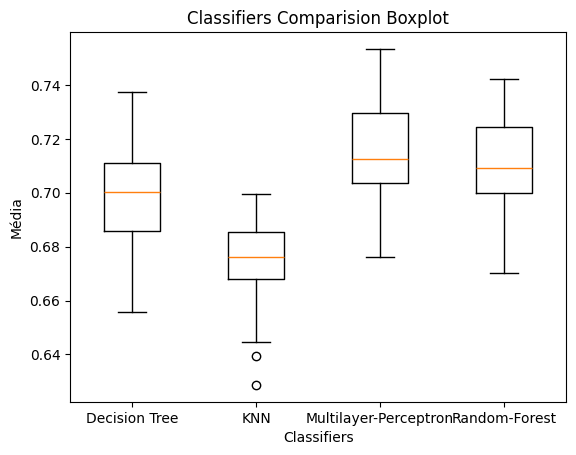

In [ ]:
plt.boxplot([resultados['DT'],resultados['KNN'],resultados['MLP'], resultados['RF']])

plt.xticks([1,2,3,4],['Decision Tree','KNN','Multilayer-Perceptron', 'Random-Forest'])
plt.xlabel("Classifiers")
plt.ylabel("Média")
plt.title("Classifiers Comparision Boxplot")
plt.show()

In [ ]:
scores_dict = {
    'DT': resultados["DT"],
    'KNN': resultados["KNN"],
    'MLP': resultados["MLP"],
    'RF': resultados["RF"],
}

modelos = list(scores_dict.keys()) #Transformando em lista para poder acessar os resultados por i e j
n = len(modelos)
matriz = [["" for _ in range(n)] for _ in range(n)]

for i in range(n):
    for j in range(n):
        if i == j:
            matriz[i][j] = modelos[i]
        elif i < j:
            t, p_t = t_corrigido_nadeau_bengio(
                scores_dict[modelos[i]],
                scores_dict[modelos[j]],
                df_x,
                n_folds_externos=10
            )
            p_t = p_t.round(3)
            if p_t <= 0.05:
              valor = f"*{p_t}*"
            else:
              valor = p_t
            matriz[i][j] = valor
        elif i > j:
            t, p_w = stats.wilcoxon(
                scores_dict[modelos[i]],
                scores_dict[modelos[j]]
            )
            p_w = p_w.round(3)
            if p_w <= 0.05:
              valor = f"*{p_w}*"
            else:
              valor = p_w
            matriz[i][j] = valor

# Criando DataFrame com pandas
tabela = pd.DataFrame(matriz)

# Exibir tabela formatada
print("Tabela pareada de p-values:")
print(tabela)

Tabela pareada de p-values:
       0      1        2        3
0     DT  *0.0*  *0.005*  *0.041*
1  *0.0*    KNN    *0.0*    *0.0*
2  *0.0*  *0.0*      MLP    0.318
3  *0.0*  *0.0*    0.051       RF
